# Cancer Prediction Data Exploration

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")


In [2]:
# Load the Cancer Prediction dataset
df = pd.read_csv('Cancer_Prediction.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Display basic info and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Display summary statistics
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## K-Nearest Neighbors (KNN) Classification

In [5]:
# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Drop 'id' column as it's not a feature
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Encode 'diagnosis' (M = malignant = 1, B = benign = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Find the most important features using correlation with the target variable
correlation = df.corr()['diagnosis'].sort_values(ascending=False)
print("Top 10 features correlated with diagnosis:\n", correlation.head(11)[1:])

# Select top 8-10 features
top_features = correlation.head(11).index[1:].tolist() # Top 10 excluding the target itself
print("\nSelected Features:", top_features)

X = df[top_features]
y = df['diagnosis']


Top 10 features correlated with diagnosis:
 concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64

Selected Features: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']


In [6]:
# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize and train the KNN classifier (k=3) just like the iris example
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of KNN (k=3): {accuracy * 100:.2f}%')


Accuracy of KNN (k=3): 90.35%


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93        76
           1       0.91      0.79      0.85        38

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



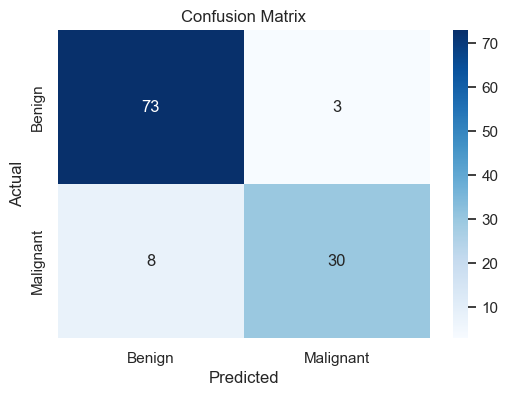

In [7]:
# Detailed Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## K-Nearest Neighbors (KNN) with ALL Features\nLet's compare the performance when we use all available features instead of just the most correlated ones.

In [8]:
# ==========================================
# KNN using ALL Features
# ==========================================

# Drop target variable and any completely empty columns (like 'Unnamed: 32' which often appears in this dataset)
X_all = df.drop('diagnosis', axis=1).dropna(axis=1, how='all')
y_all = df['diagnosis']

print("Number of features used:", X_all.shape[1])

# Split the data
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2)

# Initialize and train KNN
knn_all = KNeighborsClassifier(n_neighbors=3)
knn_all.fit(X_train_all, y_train_all)

# Make predictions
y_pred_all = knn_all.predict(X_test_all)

# Calculate accuracy
accuracy_all = accuracy_score(y_test_all, y_pred_all)
print(f'Accuracy of KNN (k=3) with ALL features: {accuracy_all * 100:.2f}%')

# Display difference
if 'accuracy' in locals():
    print(f'\nAccuracy Difference (All Features - Top Features): {(accuracy_all - accuracy) * 100:.2f}%')
else:
    print('\nRun the previous Top Features KNN cell to see the accuracy difference!')


Number of features used: 30


Accuracy of KNN (k=3) with ALL features: 93.86%

Accuracy Difference (All Features - Top Features): 3.51%


Classification Report (All Features):
               precision    recall  f1-score   support

           0       0.96      0.95      0.95        76
           1       0.90      0.92      0.91        38

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



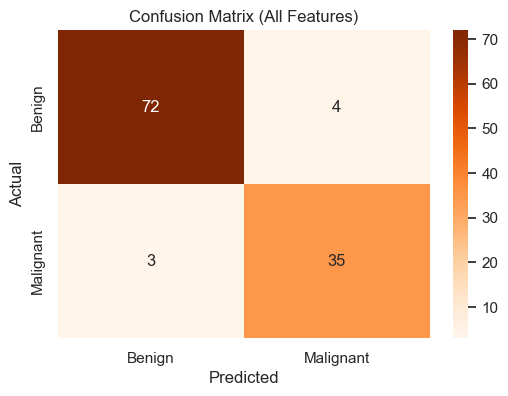

In [9]:
# Detailed Evaluation for ALL features
print("Classification Report (All Features):\n", classification_report(y_test_all, y_pred_all))

# Plot confusion matrix for all features
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_all, y_pred_all), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (All Features)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## K-Nearest Neighbors (KNN) with TOP 5 Features\nNow let's see what happens if we reduce the dataset to only the top 5 most important features.

In [10]:
# ==========================================
# KNN using ONLY the Top 5 Features
# ==========================================

# Select only top 5 most correlated features
top5_features = correlation.head(6).index[1:].tolist()
print("Selected Top 5 Features:", top5_features)

X_top5 = df[top5_features]
y_top5 = df['diagnosis']

# Split the data
X_train_top5, X_test_top5, y_train_top5, y_test_top5 = train_test_split(X_top5, y_top5, test_size=0.2, random_state=42)

# Initialize and train KNN
knn_top5 = KNeighborsClassifier(n_neighbors=3)
knn_top5.fit(X_train_top5, y_train_top5)

# Make predictions
y_pred_top5 = knn_top5.predict(X_test_top5)

# Calculate accuracy
accuracy_top5 = accuracy_score(y_test_top5, y_pred_top5)
print(f'Accuracy of KNN (k=3) with TOP 5 features: {accuracy_top5 * 100:.2f}%')

# Compare with previous models if they exist in the session
if 'accuracy_all' in locals():
    print(f'\nDifference (Top 5 vs All Features): {(accuracy_top5 - accuracy_all) * 100:.2f}%')
if 'accuracy' in locals():
    print(f'Difference (Top 5 vs Top 10 Features): {(accuracy_top5 - accuracy) * 100:.2f}%')


Selected Top 5 Features: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']
Accuracy of KNN (k=3) with TOP 5 features: 94.74%

Difference (Top 5 vs All Features): 0.88%
Difference (Top 5 vs Top 10 Features): 4.39%


Classification Report (Top 5 Features):
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        71
           1       1.00      0.86      0.93        43

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



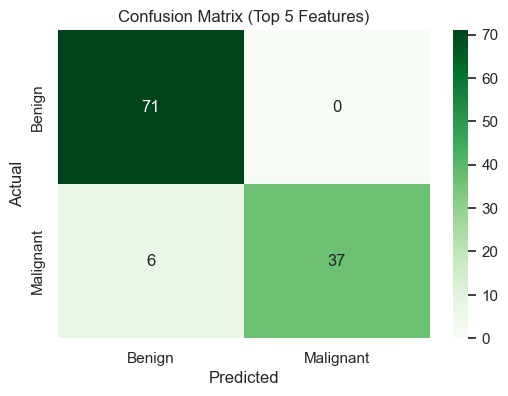

In [11]:
# Detailed Evaluation for Top 5 features
print("Classification Report (Top 5 Features):\n", classification_report(y_test_top5, y_pred_top5))

# Plot confusion matrix for Top 5 features
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_top5, y_pred_top5), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Top 5 Features)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## Visualizing the Data\nLet's visualize how the dataset separates based on the two most important features using a scatter plot.

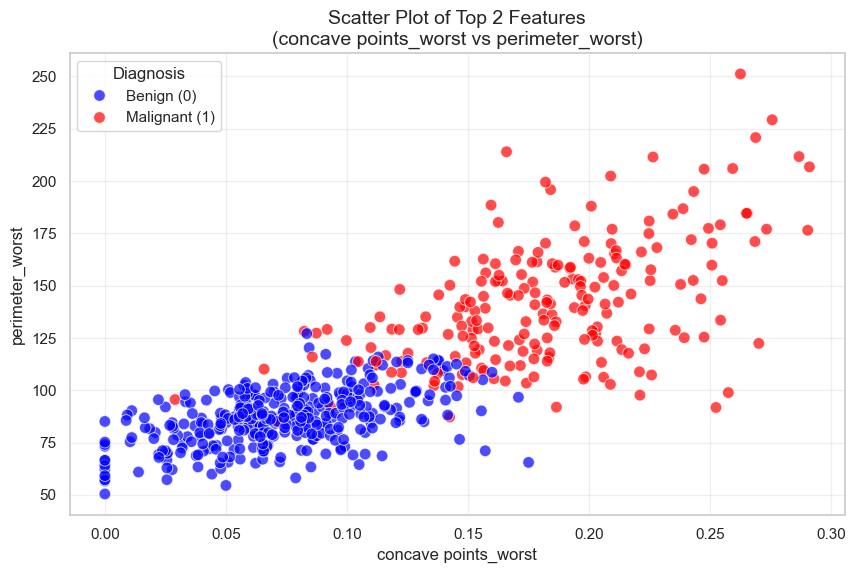

In [12]:
# ==========================================
# Visualizing the Top 2 Features
# ==========================================

# Let's create a scatter plot of the two most important features
feature_1 = top5_features[0]
feature_2 = top5_features[1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=feature_1, 
    y=feature_2, 
    hue='diagnosis', 
    data=df, 
    palette={0: 'blue', 1: 'red'}, 
    alpha=0.7,
    s=70
)

# Customize the plot
plt.title(f'Scatter Plot of Top 2 Features\n({feature_1} vs {feature_2})', fontsize=14)
plt.xlabel(feature_1, fontsize=12)
plt.ylabel(feature_2, fontsize=12)

# Update legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Benign (0)', 'Malignant (1)'], title='Diagnosis')

plt.grid(True, alpha=0.3)
plt.show()


## Support Vector Machine (SVM)\nNow let's apply the SVM algorithm to the dataset (using all features) and compare its accuracy with our KNN approach.

In [13]:
# ==========================================
# Support Vector Machine (SVM) Approach
# ==========================================
from sklearn.svm import SVC

# We will use the 'All Features' dataset for a fair comparison
# Initialize the SVM classifier (using a linear kernel as a starting point)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_all, y_train_all)

# Make predictions
y_pred_svm = svm_model.predict(X_test_all)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test_all, y_pred_svm)
print(f'Accuracy of SVM (All features): {accuracy_svm * 100:.2f}%')

# Compare with KNN (All features)
if 'accuracy_all' in locals():
    print(f'Accuracy of KNN (All features): {accuracy_all * 100:.2f}%')
    diff = (accuracy_svm - accuracy_all) * 100
    if diff > 0:
        print(f'\nResult: SVM is better by {abs(diff):.2f}%')
    elif diff < 0:
        print(f'\nResult: KNN is better by {abs(diff):.2f}%')
    else:
        print("\nResult: Both approaches have the exact same accuracy!")


Accuracy of SVM (All features): 96.49%
Accuracy of KNN (All features): 93.86%

Result: SVM is better by 2.63%


Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        76
           1       0.97      0.92      0.95        38

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



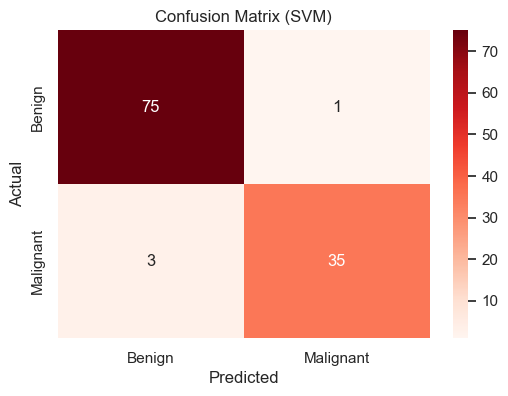

In [14]:
# Detailed Evaluation for SVM
print("Classification Report (SVM):\n", classification_report(y_test_all, y_pred_svm))

# Plot confusion matrix for SVM
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_all, y_pred_svm), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (SVM)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## K-Means Clustering\nNow we'll use an **unsupervised** approach. We'll run multiple iterations to find the optimal number of clusters (The Elbow Method) and then visualize how well the clusters align with the true diagnosis.

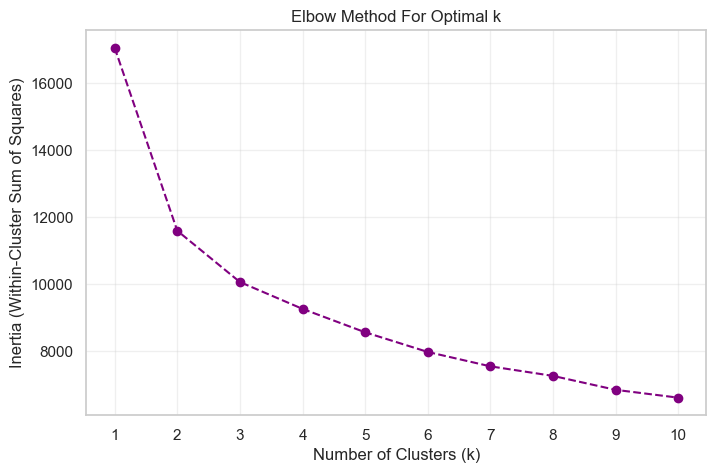

In [15]:
# ==========================================
# K-Means Clustering (Unsupervised Learning)
# ==========================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# K-Means is highly sensitive to the scale of the data, so we MUST scale it first!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Multiple Iterations (The Elbow Method) to find the optimal number of clusters (k)
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='purple')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()


Cross-Tabulation of True Diagnosis vs Clusters:


Cluster,0,1
True_Diagnosis,,
Benign,339,18
Malignant,36,176


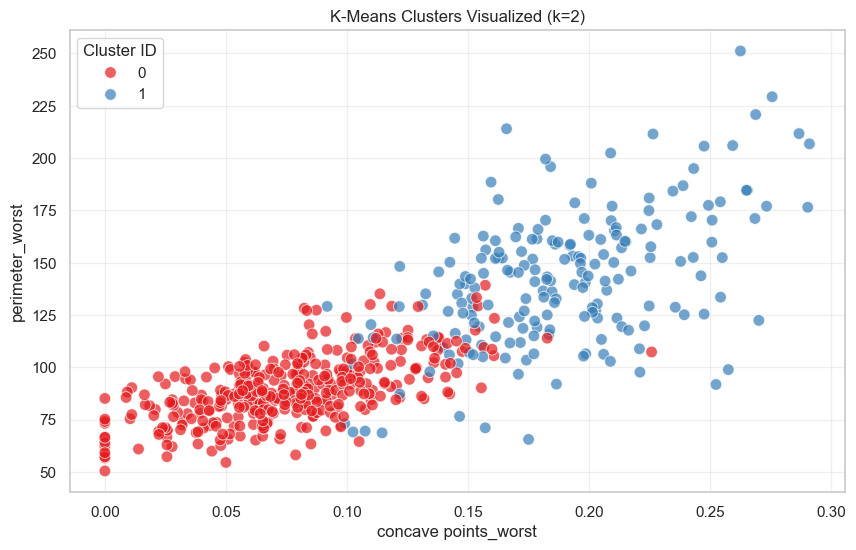

In [16]:
# Fit K-Means with optimal clusters (k=2, since we know there are 2 actual classes: Benign and Malignant)
optimal_k = 2
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Let's compare the unsupervised clusters to the true labels!
# Note: K-Means doesn't know what "Malignant" or "Benign" is, it just groups mathematically similar data points.
comparison_df = pd.DataFrame({'True_Diagnosis': y_all, 'Cluster': cluster_labels})

# Map true diagnosis back to names for readability
comparison_df['True_Diagnosis'] = comparison_df['True_Diagnosis'].map({0: 'Benign', 1: 'Malignant'})

# Create a cross-tabulation to see how the clusters align with the actual diagnosis
cross_tab = pd.crosstab(comparison_df['True_Diagnosis'], comparison_df['Cluster'])
print("Cross-Tabulation of True Diagnosis vs Clusters:")
display(cross_tab)

# Plot a scatter plot of the clusters using the Top 2 features (from earlier) to visualize the grouping
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df[top5_features[0]], 
    y=df[top5_features[1]], 
    hue=cluster_labels, 
    palette='Set1', 
    alpha=0.7,
    s=70
)
plt.title(f'K-Means Clusters Visualized (k={optimal_k})')
plt.xlabel(top5_features[0])
plt.ylabel(top5_features[1])
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()
